In [152]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Dropout, MaxPooling1D, BatchNormalization, LeakyReLU, GlobalAveragePooling1D, GlobalMaxPooling1D, PReLU
from tensorflow.keras.utils import to_categorical, register_keras_serializable
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [153]:
dataset_path = 'Combined Data.csv'
data = pd.read_csv(dataset_path)
processed_data = data.dropna()
features = ['Time Stamp', 'A1 X-Axis', 'A1 Y-Axis', 'A1 Z-Axis', 
            'G1 X-Axis', 'G1 Y-Axis', 'G1 Z-Axis', 
            'A2 X-Axis', 'A2 Y-Axis', 'A2 Z-Axis', 
            'G2 X-Axis', 'G2 Y-Axis', 'G2 Z-Axis']
X = processed_data[features]
y = processed_data['ActivityLabel']
scaler = StandardScaler()
X = scaler.fit_transform(X)
label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(y)
y = to_categorical(y)
X = np.array(X).reshape((X.shape[0], X.shape[1], 1))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [154]:
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_classes), y=y_train_classes)
class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)

# Define Focal Loss Function
@register_keras_serializable()
def focal_loss(alpha=0.25, gamma=2.0):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        loss = -alpha * y_true * K.pow(1 - y_pred, gamma) * K.log(y_pred)
        return K.mean(loss, axis=-1)
    return focal_loss_fixed


Class Weights: {0: 0.7202597504205297, 1: 1.635023532545955}


Epoch 1/50


c:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3683/3683 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8608 - loss: 0.0154 - val_accuracy: 0.9021 - val_loss: 0.0107
Epoch 2/50
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9015 - loss: 0.0101 - val_accuracy: 0.9263 - val_loss: 0.0079
Epoch 3/50
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9082 - loss: 0.0090 - val_accuracy: 0.9258 - val_loss: 0.0072
Epoch 4/50
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9147 - loss: 0.0082 - val_accuracy: 0.9201 - val_loss: 0.0075
Epoch 5/50
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9172 - loss: 0.0078 - val_accuracy: 0.9309 - val_loss: 0.0069
Epoch 6/50
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9202 - loss: 0.0075 - val_accuracy: 0.9373 - val_loss: 0.0063
Epoch 7/50
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9243 - loss: 0.0071 - val_accuracy: 0.9383 - val_loss: 0.0057
Epoch 8/50
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9244 - loss: 0.0070 - val

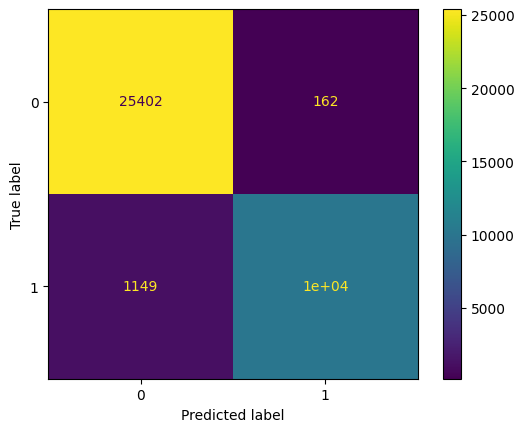

In [157]:
model = Sequential([
    Conv1D(filters=128, kernel_size=4, input_shape=(X_train.shape[1], X_train.shape[2])),
    PReLU(),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=256, kernel_size=4),
    # LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    GlobalMaxPooling1D(),
    # GlobalAveragePooling1D(),
    Dense(512),
    PReLU(),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=focal_loss(alpha=0.25, gamma=2.0), metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(filepath='cnn_activity_model.keras', save_best_only=True, monitor='val_loss')
]

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    class_weight=class_weights,
    callbacks=callbacks
)

# Evaluate the model
y_pred = model.predict(X_test)
threshold = 0.6
y_pred_classes = (y_pred[:, 1] > threshold).astype(int)
y_true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))

if y_test.shape[1] == 2:
    roc_auc_value = roc_auc_score(y_test[:, 1], y_pred[:, 1])
    print(f"ROC-AUC Score: {roc_auc_value:.4f}")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_true_classes, y_pred_classes)

# Save the final model
model.save("final_cnn_activity_model.keras")
print("\nModel saved as final_cnn_activity_model.keras")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Reading 1: Predicted ActivityLabel = 0
Reading 2: Predicted ActivityLabel = 0
Reading 3: Predicted ActivityLabel = 0
Reading 4: Predicted ActivityLabel = 0
Reading 5: Predicted ActivityLabel = 0
Reading 6: Predicted ActivityLabel = 0
Reading 7: Predicted ActivityLabel = 0
Reading 8: Predicted ActivityLabel = 0
Reading 9: Predicted ActivityLabel = 0
Reading 10: Predicted ActivityLabel = 0
Reading 11: Predicted ActivityLabel = 0
Reading 12: Predicted ActivityLabel = 0
Reading 13: Predicted ActivityLabel = 0
Reading 14: Predicted ActivityLabel = 0
Reading 15: Predicted ActivityLabel = 0
Reading 16: Predicted ActivityLabel = 0
Reading 17: Predicted ActivityLabel = 0
Reading 18: Predicted ActivityLabel = 0
Reading 19: Predicted ActivityLabel = 0
Reading 20: Predicted ActivityLabel = 0
Reading 21: Predicted ActivityLabel = 0
Reading 22: Predicted ActivityLabel = 0
Reading 23: Predicted ActivityLabel = 0
Reading 24: Predicted ActivityLabel = 0
Reading 25:

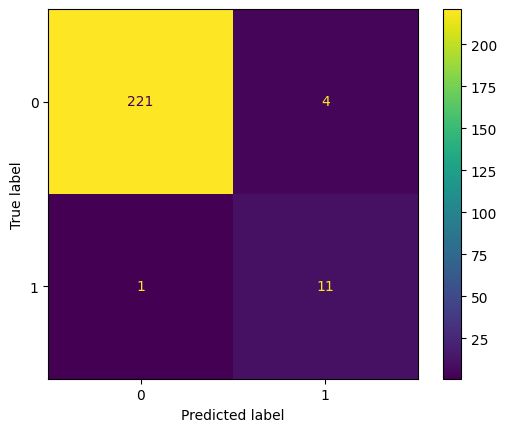

In [158]:
from keras.models import load_model

def focal_loss(alpha=0.25, gamma=2.0):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        loss = -y_true * (alpha * K.pow(1 - y_pred, gamma) * K.log(y_pred))
        return K.mean(loss, axis=-1)
    return focal_loss_fixed

# Load the model
model = load_model('cnn_activity_model.keras', custom_objects={'focal_loss_fixed': focal_loss(alpha=0.25, gamma=2.0)})

# Load the new test dataset
new_data_path = 'Test.csv'
new_data = pd.read_csv(new_data_path)
new_data = new_data.dropna()

# Define features and labels
features = ['Time Stamp', 'A1 X-Axis', 'A1 Y-Axis', 'A1 Z-Axis', 'G1 X-Axis', 
            'G1 Y-Axis', 'G1 Z-Axis', 'A2 X-Axis', 'A2 Y-Axis', 'A2 Z-Axis', 
            'G2 X-Axis', 'G2 Y-Axis', 'G2 Z-Axis']
X_new = new_data[features]
y_true_classes_new = new_data['ActivityLabel']

# Normalize and reshape the test data
X_new = (X_new - np.mean(X_new, axis=0)) / np.std(X_new, axis=0)
X_new = np.array(X_new).reshape((X_new.shape[0], X_new.shape[1], 1))

# Predict with the model
y_pred_new = model.predict(X_new)
threshold = 0.85
y_pred_classes_new = (y_pred_new[:, 1] > threshold).astype(int)

# Display predictions for each reading
for i, pred in enumerate(y_pred_classes_new):
    print(f"Reading {i+1}: Predicted ActivityLabel = {pred}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes_new, y_pred_classes_new))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(y_true_classes_new, y_pred_classes_new)


In [141]:
# Convert the model to a C-compatible format
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

def save_weights_to_h_file(model, output_file):
    """
    Save weights and biases of the CNN model to a header (.h) file without duplicate definitions.
    """
    with open(output_file, "w") as f:
        f.write("#ifndef CNN_WEIGHTS_H\n#define CNN_WEIGHTS_H\n\n")
        f.write("// Automatically generated weights and biases for CNN model\n\n")

        seen_variables = {}  # Dictionary to track variable names and ensure uniqueness

        for layer in model.layers:
            if len(layer.get_weights()) > 0:
                weights = layer.get_weights()

                # Save weights
                weights_name = f"{layer.name}_weights"
                if weights_name not in seen_variables and len(weights) > 0:
                    seen_variables[weights_name] = True
                    f.write(f"const float {weights_name}[] = {{\n")
                    np.savetxt(f, weights[0].flatten(), delimiter=", ", newline=", ")
                    f.write("\n};\n\n")

                # Save biases
                biases_name = f"{layer.name}_biases"
                if biases_name not in seen_variables and len(weights) > 1:
                    seen_variables[biases_name] = True
                    f.write(f"const float {biases_name}[] = {{\n")
                    np.savetxt(f, weights[1].flatten(), delimiter=", ", newline=", ")
                    f.write("\n};\n\n")

        f.write("#endif // CNN_WEIGHTS_H\n")

    print(f"Weights and biases saved to {output_file}.")

def generate_c_code(model, header_file, output_file):
    """
    Generate C code for the CNN inference using the weights from the header file.
    """
    with open(output_file, "w") as f:
        f.write("// CNN Model Inference Code\n")
        f.write("#include <math.h>\n")
        f.write("#include <stdlib.h>\n")
        f.write("#include <stdio.h>\n")
        f.write(f"#include \"{header_file}\"\n\n")
        
        # Add functions for layers
        f.write("// Conv1D Implementation\n")
        f.write("""
void conv1d(float *input, float *output, const float *kernel, const float *bias, int input_size, int kernel_size, int filters) {
    for (int f = 0; f < filters; f++) {
        for (int i = 0; i < input_size - kernel_size + 1; i++) {
            float sum = bias[f];
            for (int k = 0; k < kernel_size; k++) {
                sum += input[i + k] * kernel[f * kernel_size + k];
            }
            output[f * (input_size - kernel_size + 1) + i] = sum > 0 ? sum : 0; // ReLU activation
        }
    }
}
        """)

        f.write("// Dense Layer Implementation\n")
        f.write("""
void dense(float *input, float *output, const float *weights, const float *bias, int input_size, int output_size) {
    for (int o = 0; o < output_size; o++) {
        float sum = bias[o];
        for (int i = 0; i < input_size; i++) {
            sum += input[i] * weights[o * input_size + i];
        }
        output[o] = sum > 0 ? sum : 0; // ReLU activation
    }
}
        """)

        f.write("// GlobalMaxPooling1D Implementation\n")
        f.write("""
void global_max_pooling1d(float *input, float *output, int input_size, int filters) {
    for (int f = 0; f < filters; f++) {
        float max_value = -INFINITY;
        for (int i = 0; i < input_size; i++) {
            if (input[f * input_size + i] > max_value) max_value = input[f * input_size + i];
        }
        output[f] = max_value;
    }
}
        """)

        f.write("// Main Inference Function\n")
        f.write("""
void cnn_inference(float *input, float *output) {
    // Implement the forward pass using the weights from the header file
    // Example:
    // conv1d(input, conv_output, conv1_weights, conv1_bias, input_size, kernel_size, filters);
    // dense(conv_output, dense_output, dense_weights, dense_bias, input_size, output_size);
}
        """)

        f.write("// Main Program (for testing)\n")
        f.write("""
int main() {
    // Example input
    float input[INPUT_SIZE] = { /* Fill with test input data */ };
    float output[OUTPUT_SIZE];
    
    // Run inference
    cnn_inference(input, output);
    
    // Print output
    for (int i = 0; i < OUTPUT_SIZE; i++) {
        printf("Output[%d] = %f\\n", i, output[i]);
    }
    return 0;
}
        """)

    print(f"C code saved to {output_file}.")

if __name__ == "__main__":
    # Load the CNN model
    model_path = "cnn_activity_model.keras"
    model = load_model(model_path, custom_objects={"focal_loss_fixed": None})

    # Save weights directly to a .h header file
    header_file = "cnn_weights.h"
    save_weights_to_header(model, header_file)

    # Generate C code for the CNN inference
    output_file = "cnn_inference.c"
    generate_c_code(model, header_file, output_file)

    print("C code and header file generated successfully.")


Weights and biases saved to cnn_weights.h.
C code saved to cnn_inference.c.
C code and header file generated successfully.
